Final Risk Analysis Table:
         Mean Return  Standard Deviation  Sharpe Ratio  VaR (95%)
AAPL        0.001120            0.019433     -0.971526  -0.030713
BTC-USD     0.002369            0.036364     -0.484845  -0.050979
JNJ         0.000356            0.012205     -1.609499  -0.016642
XOM         0.000557            0.020770     -0.936107  -0.032322


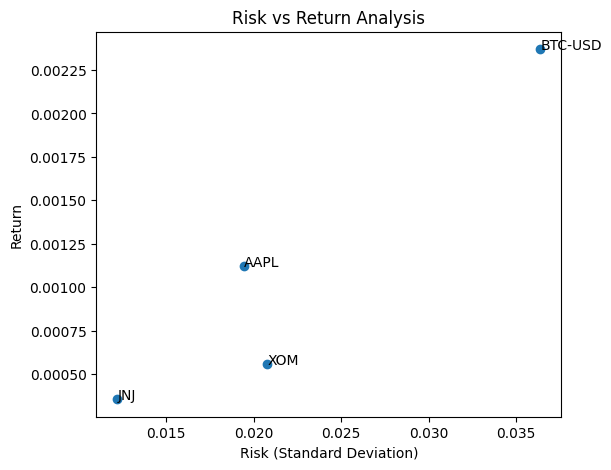

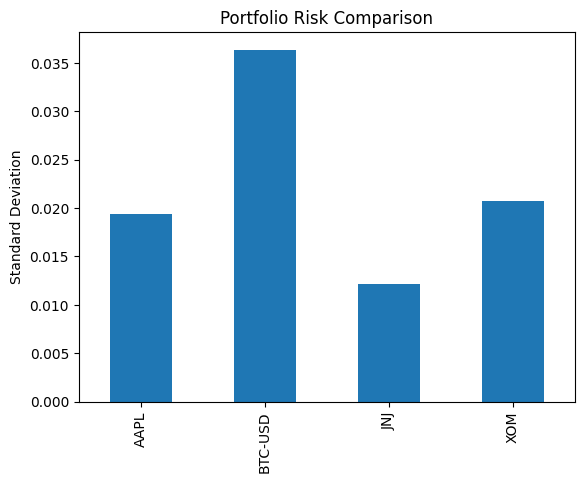

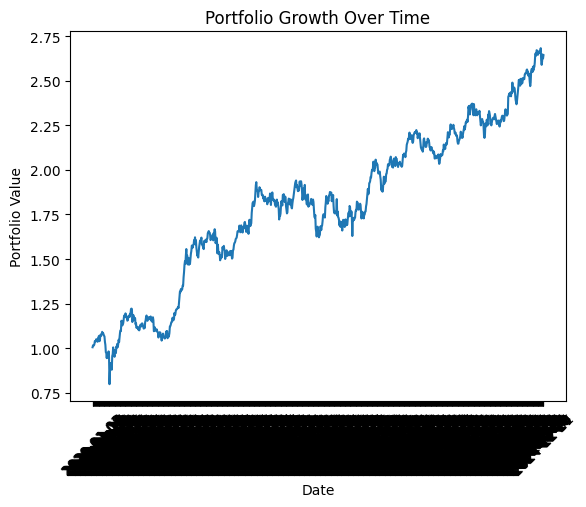

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load CSV files
returns = pd.read_csv("stock_returns.csv")
portfolio = pd.read_csv("portfolio_summary.csv")

# Remove date column for calculations
returns = returns.drop(columns=["Date"])

# Calculate metrics
mean_returns = returns.mean()
std_dev = returns.std()
var_95 = returns.quantile(0.05)

risk_free_rate = 0.02
sharpe_ratio = (mean_returns - risk_free_rate) / std_dev

# Create final results table
results = pd.DataFrame({
    "Mean Return": mean_returns,
    "Standard Deviation": std_dev,
    "Sharpe Ratio": sharpe_ratio,
    "VaR (95%)": var_95
})

print("Final Risk Analysis Table:")
print(results)

# -------- Risk vs Return Scatter Plot --------
plt.figure(figsize=(6,5))
plt.scatter(std_dev, mean_returns)

for asset in mean_returns.index:
    plt.text(std_dev[asset], mean_returns[asset], asset)

plt.xlabel("Risk (Standard Deviation)")
plt.ylabel("Return")
plt.title("Risk vs Return Analysis")
plt.show()

# -------- Risk Comparison Bar Chart --------
std_dev.plot(kind="bar")
plt.title("Portfolio Risk Comparison")
plt.ylabel("Standard Deviation")
plt.show()

# -------- Portfolio Growth Chart --------
plt.figure(figsize=(10,5))

portfolio["Date"] = pd.to_datetime(portfolio["Date"])

plt.plot(portfolio["Date"][::20], portfolio["Portfolio_Value"][::20])

plt.title("Portfolio Growth Over Time")
plt.xlabel("Date")
plt.ylabel("Portfolio Value")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()